In [1]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/sdtool_load_test/sdtools"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
plt.style.use('default')
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['axes.grid'] = True
plt.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


# I/O

In [2]:
parent_dir = '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/'
powers = ['50%', '100%', '300%']
models = ['FL', 'SNB']

# to_load = ['/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/300%_fluence/power_and_density/FL/case_01',
#            '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/300%_fluence/power_only/FL/case_01'
#             ]

cs = dict()

for power in powers:
    for model in models:
        name = f"{power}_{model}"
        cs[name] = Load.case_1D(parent_dir + f"{power}_fluence/power_and_density/{model}/case_01", guard_replace = False, use_squash=True)

# for power in powers:
#     name = f"{power}_FL_power_only"
#     print(f"Loading {name}")
#     cs[name] = Load.case_1D(parent_dir + f"{power}_fluence/power_only/FL/case_01", guard_replace = False, use_squash=True)
# # names = ['power_and_density', 'power_only']



# for index,i in enumerate(to_load):
#     i = Path(i)
#     name = f"{names[index]}"
#     print(f"Loading {name}")
#     cs[name] = Load.case_1D(i, guard_replace = False, use_squash=True)

print(cs.keys())

- Looking for squash file
- Squash file found. squash date 04/23/2025, 19:23:18, dmp file date 11/26/2024, 05:37:12
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 04/16/2025, 18:02:03, dmp file date 11/26/2024, 05:59:49
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 04/23/2025, 19:38:22, dmp file date 11/26/2024, 05:37:45
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 05/09/2025, 13:03:46, dmp file date 11/26/2024, 06:05:39
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 04/23/2025, 20:04:43, dmp file date 11/26/2024, 06:50:17
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 04/16/2025, 18:30:00, dmp file date 11/26/2024, 06:31:16
Skipping unnormalisation
dict_keys(['50%_FL', '50%_SNB', '100%_FL', '100%_SNB', '300%_FL', '300%_SNB'])


# Snapshot

/tmp/ipykernel_3035793/203218592.py:50: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  a.set_ybound(0, 10000)


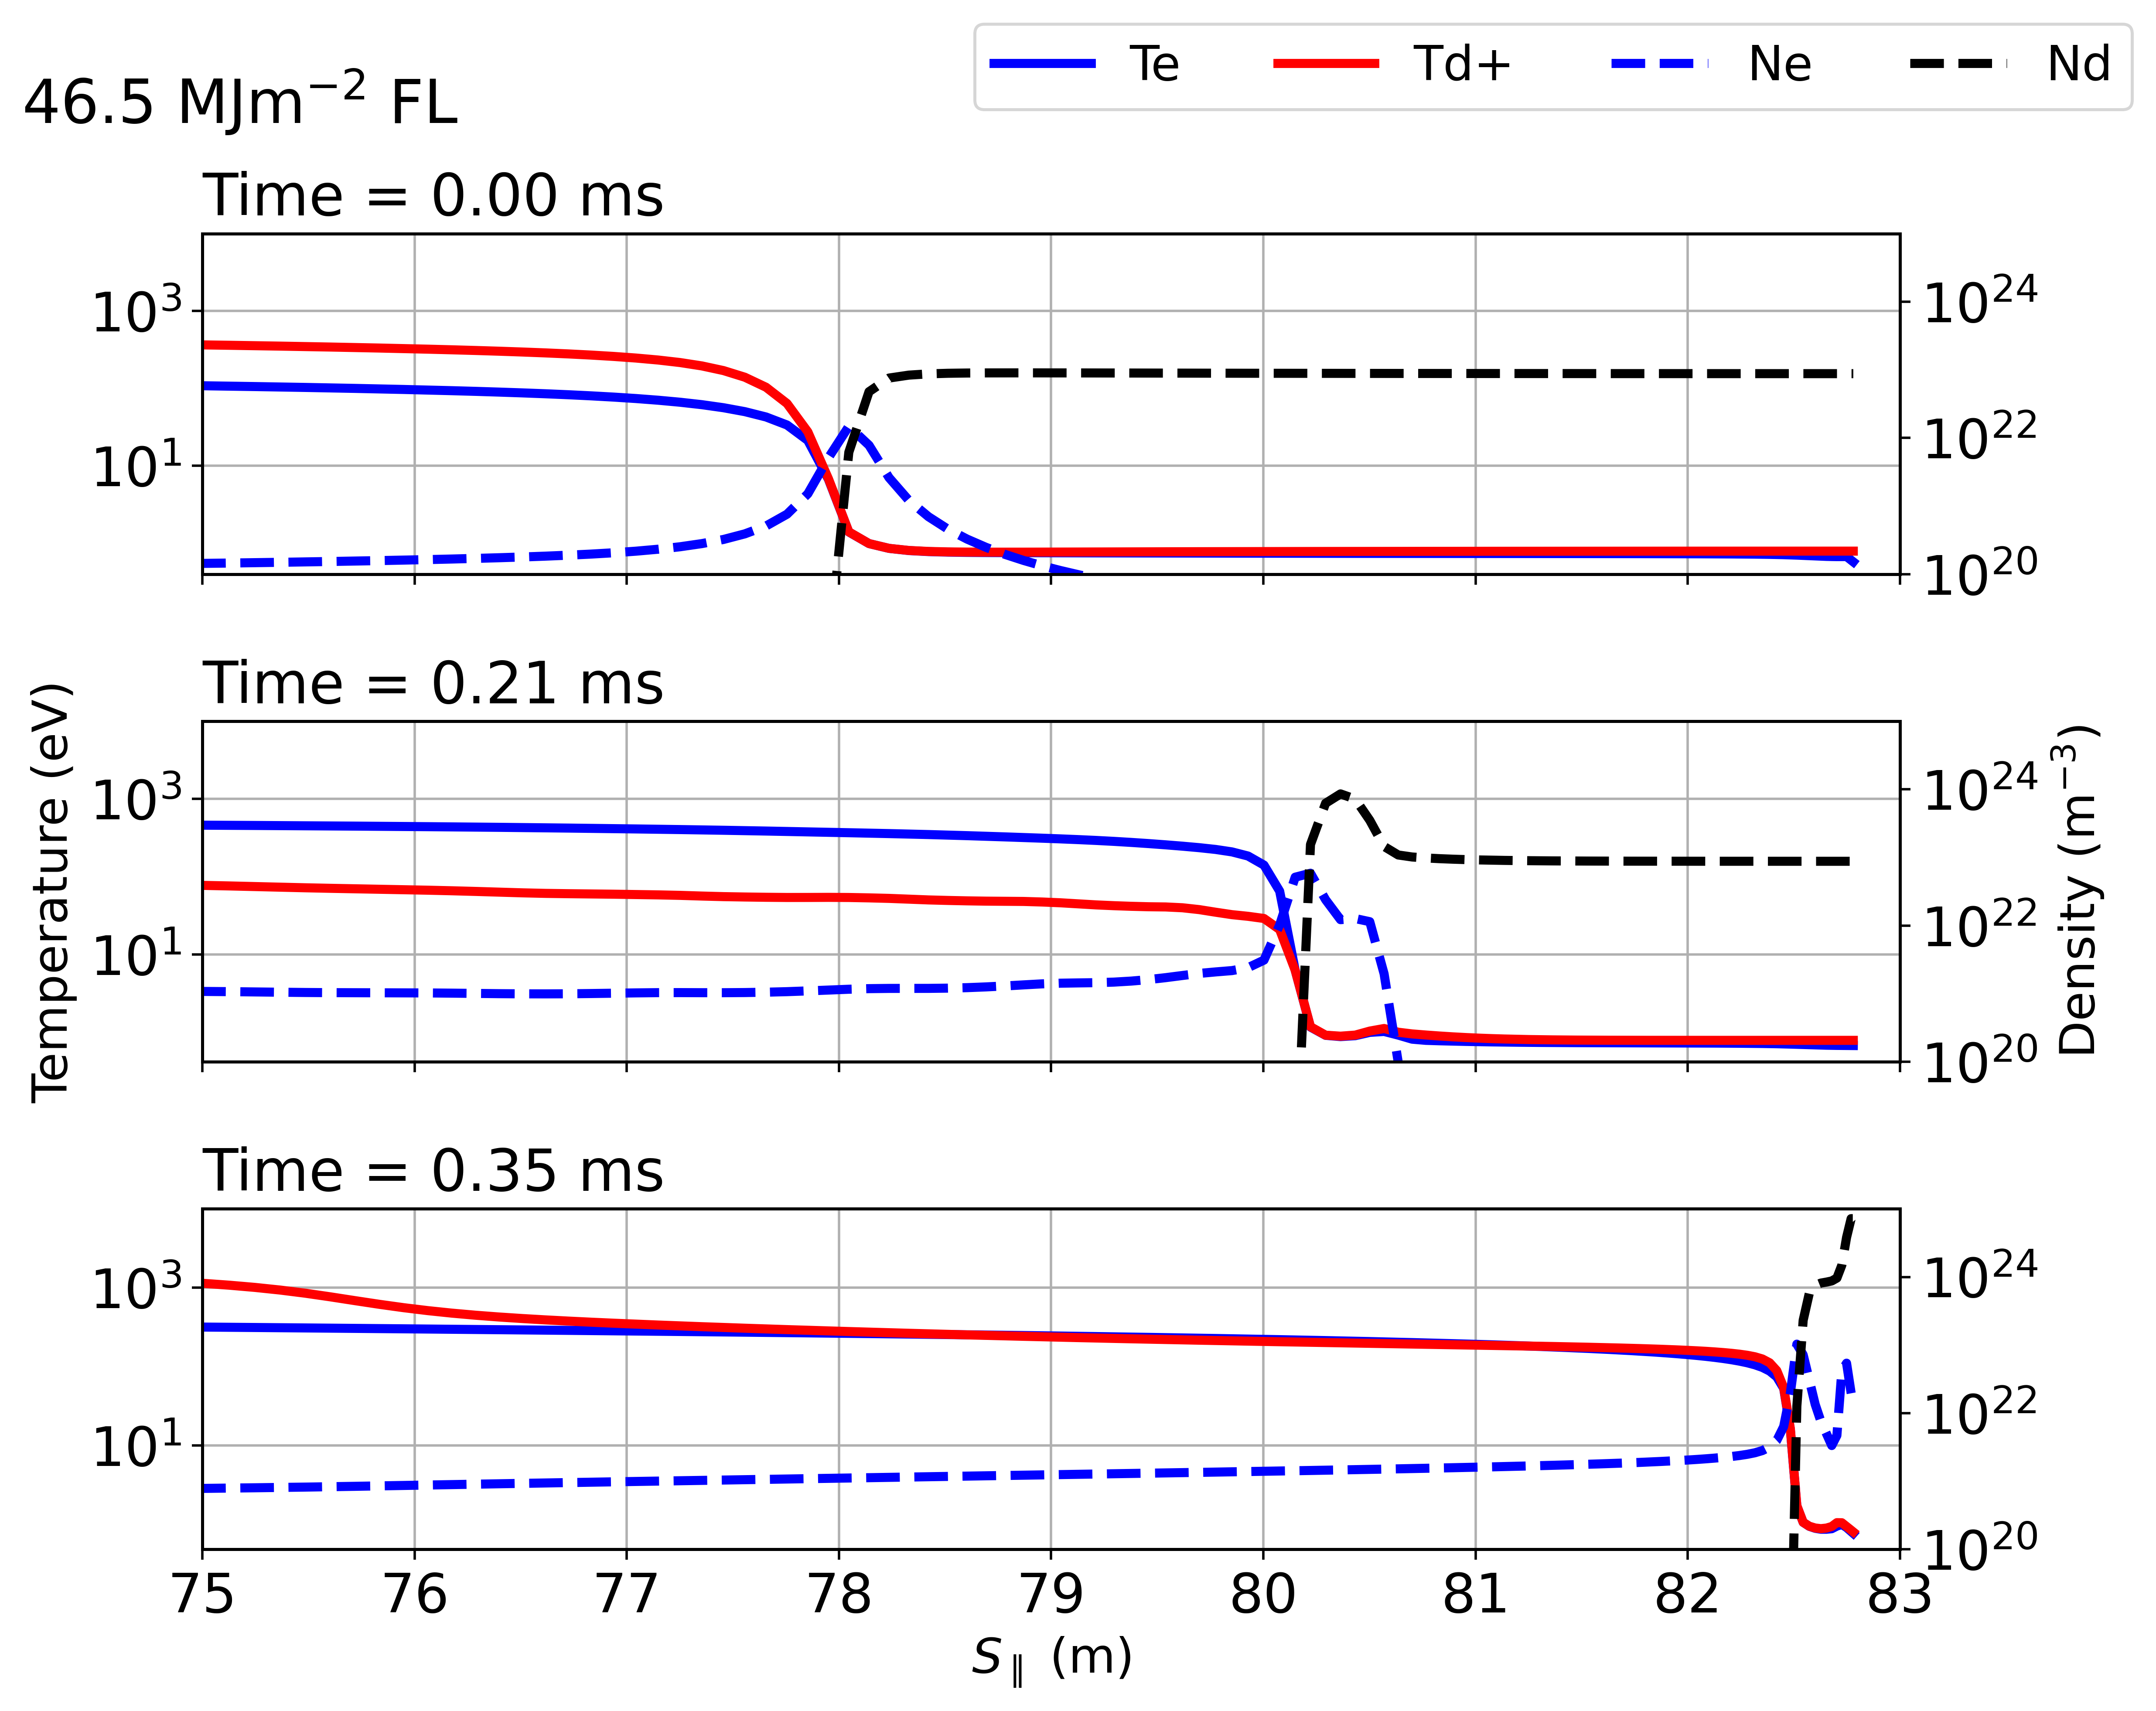

In [15]:
times = [48, 68,  81]

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True, dpi=500)

ax12 = ax[0].twinx()
ax22 = ax[1].twinx()
ax32 = ax[2].twinx()

case_name = '300%_FL'

for i, t in enumerate(times):
    case = cs[f'{case_name}'].ds.isel(t=t)
    y = replace_guards(case['y'].values)
    Te = replace_guards(case['Te'].values)
    Ti = replace_guards(case['Td+'].values)
    Ne = replace_guards(case['Ne'].values)
    Nd = replace_guards(case['Nd'].values)
    # Only add labels for the first subplot
    if i == 0:
        ax[i].plot(y, Te, label='Te', color='blue', linewidth=linewidth)
        ax[i].plot(y, Ti, label='Td+', color='red',linewidth=linewidth)
        ax12.plot(y, Ne, label='Ne', color='blue', linestyle='--',linewidth=linewidth)
        ax12.plot(y, Nd, label='Nd', color='black', linestyle='--',linewidth=linewidth)
    else:
        ax[i].plot(y, Te, color='blue',linewidth=linewidth)
        ax[i].plot(y, Ti, color='red',linewidth=linewidth)
        if i == 1:
            ax22.plot(y, Ne, color='blue', linestyle='--',linewidth=linewidth)
            ax22.plot(y, Nd, color='black', linestyle='--',linewidth=linewidth)
        else:
            ax32.plot(y, Ne, color='blue', linestyle='--',linewidth=linewidth)
            ax32.plot(y, Nd, color='black', linestyle='--',linewidth=linewidth)
    time = ((case['t'].values - cs[f'{case_name}'].ds.isel(t=0)['t'])*1e3) # Convert to ms
    ax[i].set_title(fr'Time = {time - 0.5:.2f} ms', loc = 'left')

# ax12.set_ylabel('Density')
ax22.set_ylabel(r'Density (m$^{-3}$)')
# ax32.set_ylabel('Density')

# Get handles and labels from the first axes and twinx
handles1, labels1 = ax[0].get_legend_handles_labels()
handles2, labels2 = ax12.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2, loc='upper right',ncols = 4)

ax[2].set_xlabel(r'$S_{\parallel}$ (m)')
ax[1].set_ylabel('Temperature (eV)')

for a in ax:
    a.set_yscale('log')
    a.set_ybound(0, 10000)

ax12.set_yscale('log')
ax22.set_yscale('log')
ax32.set_yscale('log')
ax12.set_ybound(1e20, 1e25)
ax22.set_ybound(1e20, 1e25)
ax32.set_ybound(1e20, 1e25)

# ax[2].invert_xaxis()
# ax[2].set_xscale('log')
ax[2].set_xbound(75, 83)
fig.suptitle(r'$46.5$ MJm$^{-2}$ FL', x=0.02, y=0.96, horizontalalignment='left', fontsize=20)

ax12.grid(False)
ax22.grid(False)
ax32.grid(False)
plt.tight_layout()
plt.show()

# Detachment

In [4]:
def front_tracking(ds, more_fronts = False):
    ds = ds.copy()
    df = pd.DataFrame()
    df.index = range(ds.dims["t"])
    dist = ds["pos"].values
    df["t"] = ds["t"]

    def find_crossing(dist, data, threshold):

        # Find indices where the temperature crosses the threshold
        final_crossing = np.where(np.diff(np.signbit(data - threshold)))[0][-1]

        # Initialize a list to store crossing times
        crossing_times = []

        # Interpolate within each crossing interval to find the exact crossing time
        t1, t2 = dist[final_crossing], dist[final_crossing + 1]
        data1, data2 = data[final_crossing], data[final_crossing + 1]

        # Linear interpolation to find the crossing time
        location = t1 + (threshold - data1) * (t2 - t1) / (data2 - data1)

        return location



    for t in range(ds.dims["t"]):

        timeslice = ds.isel(t=t)
        df.loc[t, "5eV"] = find_crossing(dist, timeslice["Te"].values, 5)

        if more_fronts is True:
            df.loc[t, "Ne_peak"] = find_crossing(dist, timeslice["Ne"].values, timeslice["Ne"].values.max())
            df.loc[t, "Rneon"] = find_crossing(dist, timeslice["Rneon"].values, timeslice["Rneon"].values.max())
            df.loc[t, "iz_peak"] = find_crossing(dist, timeslice["Sd+_iz"].values, timeslice["Sd+_iz"].values.max())
            df.loc[t, "rec_peak"] = find_crossing(dist, timeslice["Sd+_rec"].values, timeslice["Sd+_rec"].values.max())

    # print(df.index)
    # print(df.index.duplicated())

    ds["front_pardist_5eV"] = xr.DataArray(df["5eV"].values, dims=["t"], coords={"t": ds["t"].values})
    ds["front_pardist_5eV"].attrs.update(dict(
        short_name = "5eV front pol. distance from target [m]",
        units = "m",
        origin = "sdtools")
    )

    
    if more_fronts is True:
        ds["front_poldist_Rpeak"] = xr.DataArray(df["Rneon"].values, dims = ["t"])
        ds["front_poldist_Rpeak"].attrs.update(dict(
            short_name = "R peak front pol. distance from target [m]",
            units = "m",
            origin = "sdtools")
        )

        ds["front_poldist_IZpeak"] = xr.DataArray(df["iz_peak"].values, dims = ["t"])
        ds["front_poldist_IZpeak"].attrs.update(dict(
            short_name = "IZ peak front pol. distance from target [m]",
            units = "m",
            origin = "sdtools")
        )

        ds["front_poldist_Nepeak"] = xr.DataArray(df["Ne_peak"].values, dims = ["t"])
        ds["front_poldist_Nepeak"].attrs.update(dict(
            short_name = "Ne peak front pol. distance from target [m]",
            units = "m",
            origin = "sdtools")
        )


    return ds
# ds["front_poldist_5eV"] = xr.DataArray(df["5eV"].values, dims = ["t"])

In [5]:
for name, case in cs.items():
    print(f"Tracking fronts for {name}")
    cs[name].ds = front_tracking(case.ds, more_fronts=True)

Tracking fronts for 50%_FL


KeyboardInterrupt: 

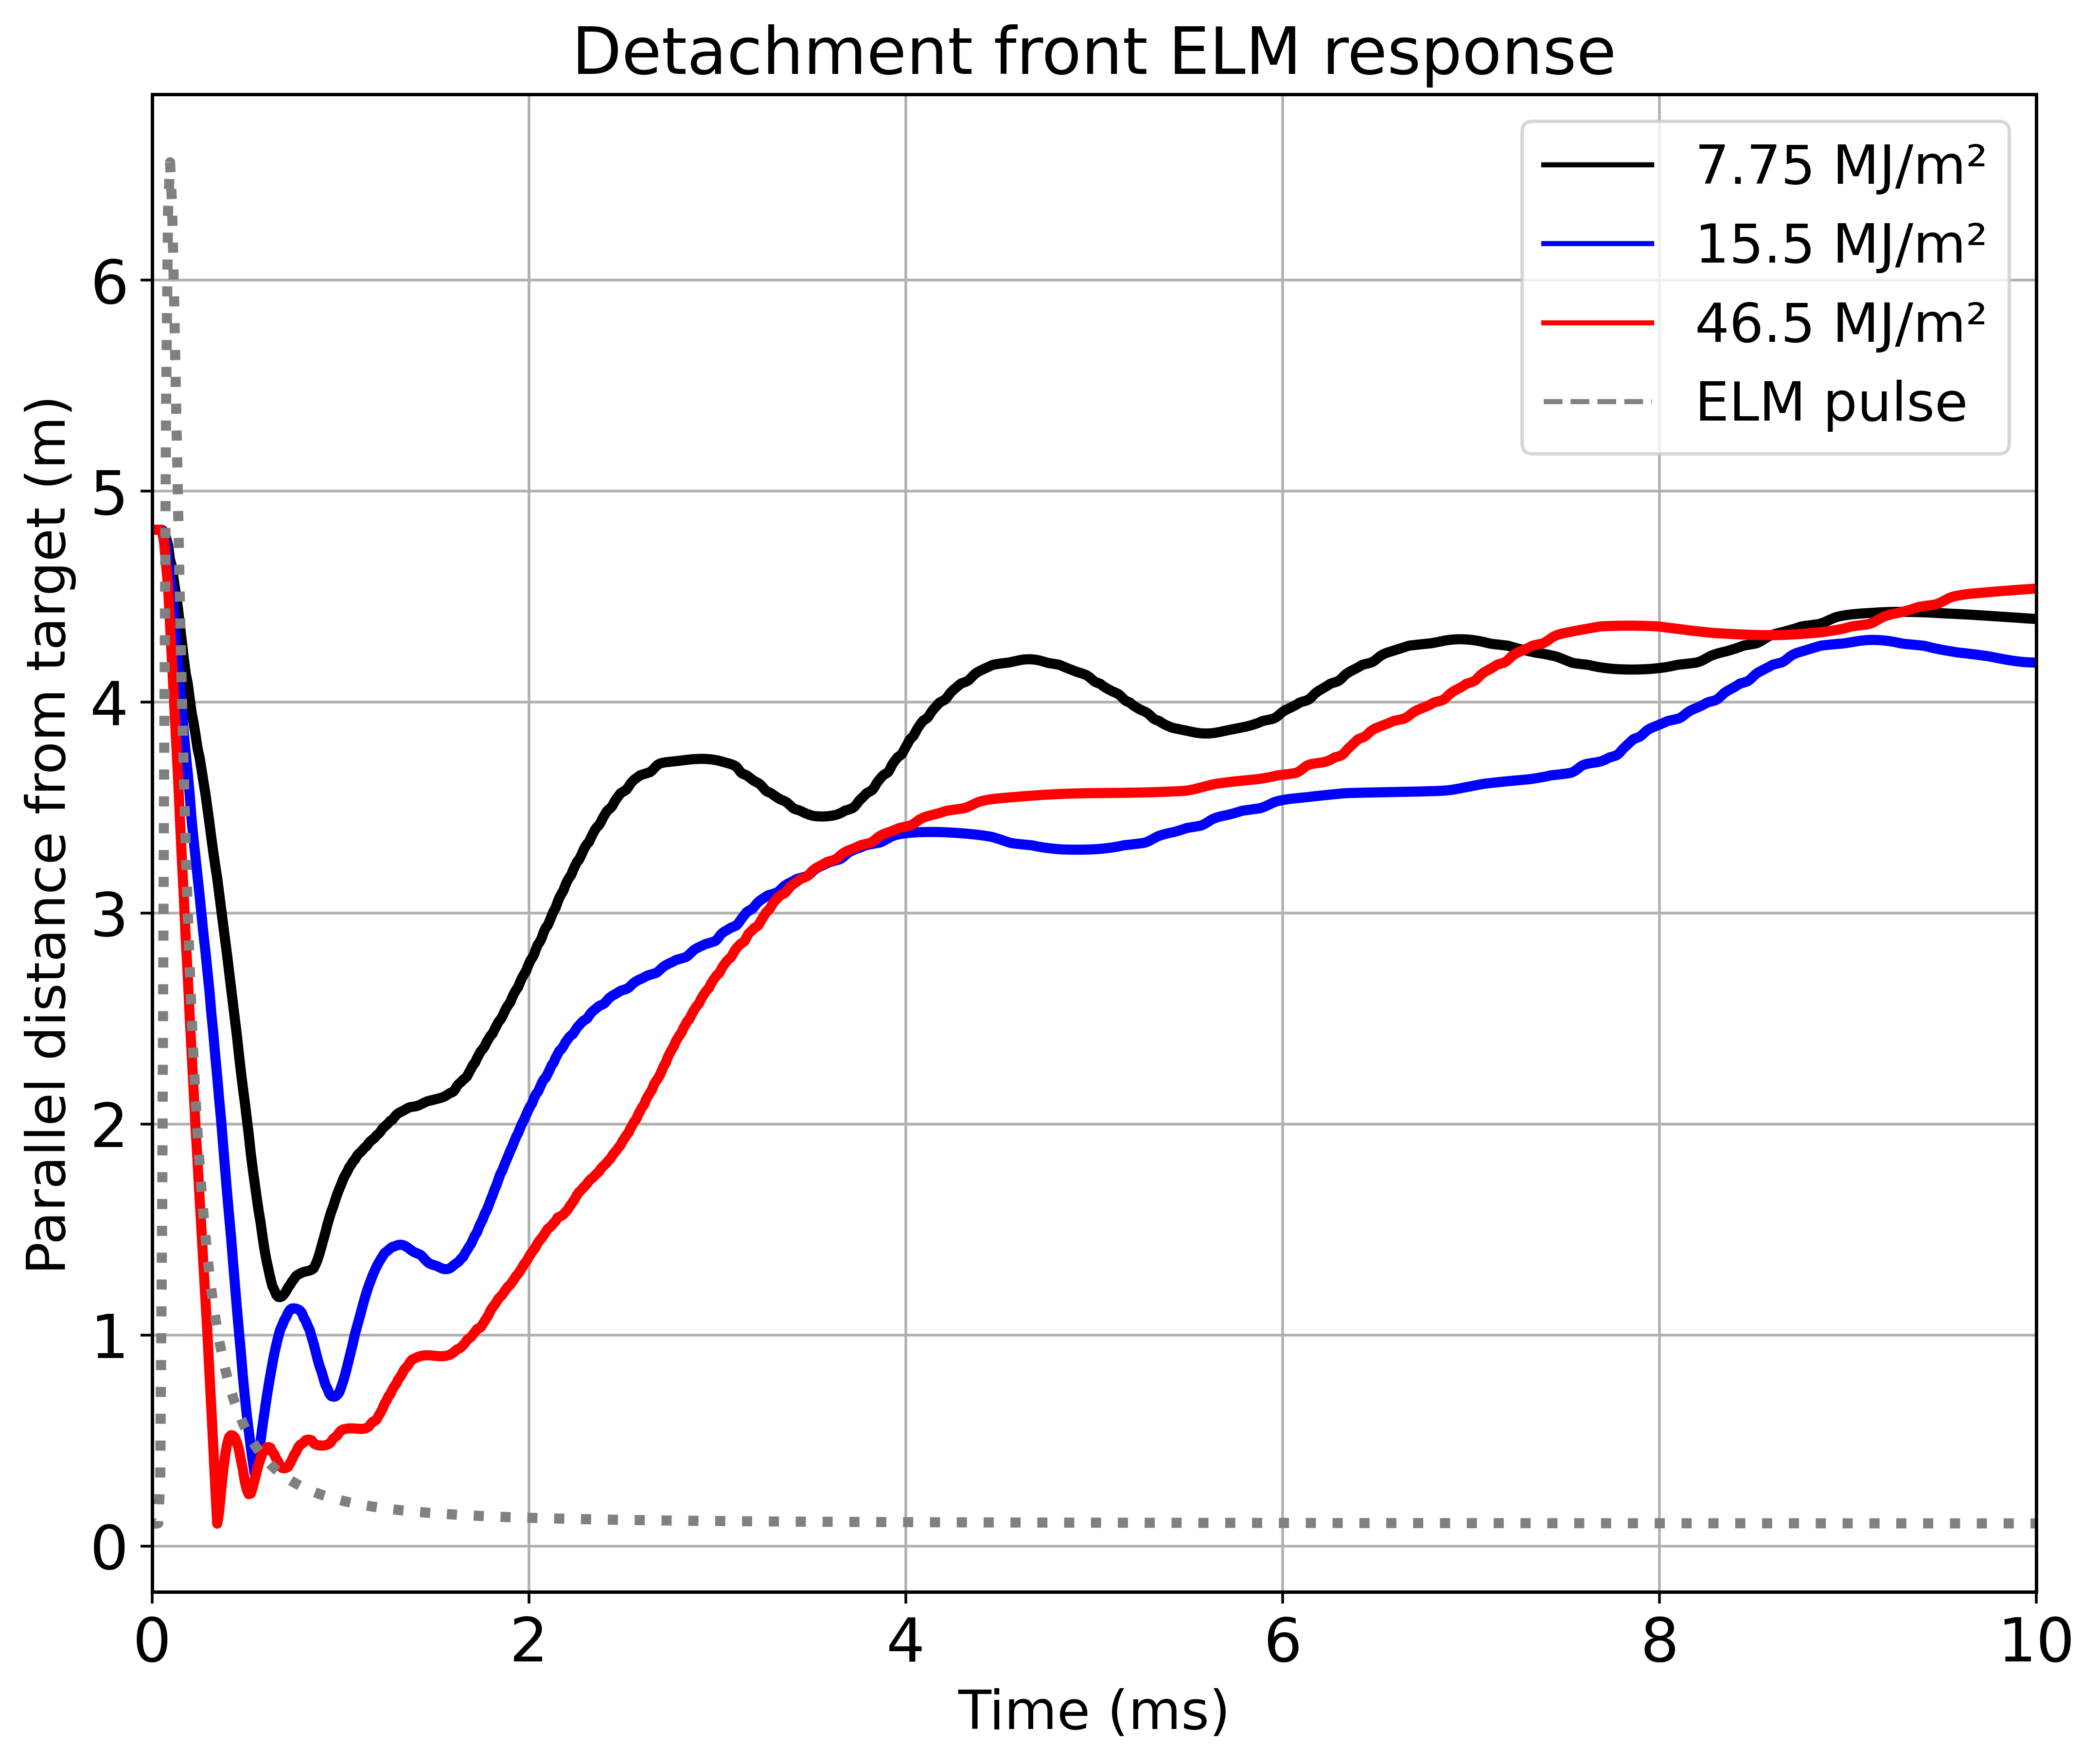

In [ ]:
import re
from matplotlib.lines import Line2D

# Plotting the fronts
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharex=True, dpi=500)
ax2 = ax.twinx()
for name, cases in cs.items():
    # Check if name contains SNB or FL using regex
    if not re.search(r'(SNB)', name):
        continue
        
    if 'FL' in name:
        linestyle = '-'
    elif 'SNB' in name:
        linestyle = '-'
    else:
        linestyle = '-'

    if '50' in name:
        color = 'black'
        energy_label = '7.75 MJ/m²'
    elif '100' in name:
        color = 'blue'
        energy_label = '15.5 MJ/m²'
    elif '300' in name:
        color = 'red'
        energy_label = '46.5 MJ/m²'
    else:
        continue  # Skip if no energy level found

    detachment = 82 - cases.ds['front_pardist_5eV'].values
    front_distance = cases.ds['front_pardist_5eV'].values
    time = (cases.ds['t'].values - cases.ds['t'].values[0]) * 1e3 - 0.5  # Convert to ms
    # ELM DURATION
    base_power = case.ds.isel(t=0)['Pe_src'].values[2]
    norm_power = case.ds.isel(pos=2)['Pe_src'].values[2] / base_power

    
    ax.plot(time, detachment, linewidth=linewidth, linestyle=linestyle, color=color)

# Create custom legend with two sections
energy_legend = [
    Line2D([0], [0], color='black', linestyle='-', label='7.75 MJ/m²'),
    Line2D([0], [0], color='blue', linestyle='-', label='15.5 MJ/m²'),
    Line2D([0], [0], color='red', linestyle='-', label='46.5 MJ/m²')
]

linestyle_legend = [
    # Line2D([0], [0], color='gray', linestyle='-', label='FL'),
    Line2D([0], [0], color='gray', linestyle='--', label='ELM pulse')
]
ax2.plot(time, case.ds['Pe_src'].isel(pos=slice(2, -2)).sum(dim='pos') - case.ds['Pe_src'].isel(pos=slice(2, -2)).sum(dim='pos')[3], linewidth=linewidth, linestyle=':', color='gray')
ax2.set_yticks([])  # Remove y ticks on second axis
# ax2.set_ylabel('ELM pulse')

# Combine legends
legend_elements = energy_legend + linestyle_legend
ax.legend(handles=legend_elements, loc='best')

ax.set_xlabel('Time (ms)')
ax.set_ylabel(' Parallel distance from target (m)')
ax.set_title('Detachment front ELM response')
ax.set_xbound(0,10)

# Burnthrough illustration

In [ ]:
older_case = Load.case_1D('/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2025-04_updated_glimmer/scenario_development/Detached/case_09_cold_start_detached_07_x2_power', guard_replace = False, use_squash=True).ds


- Looking for squash file
- Squash file found. squash date 06/29/2025, 21:28:52, dmp file date 04/27/2025, 10:19:18
Skipping unnormalisation


In [ ]:
det_front = front_tracking(older_case, more_fronts=True)



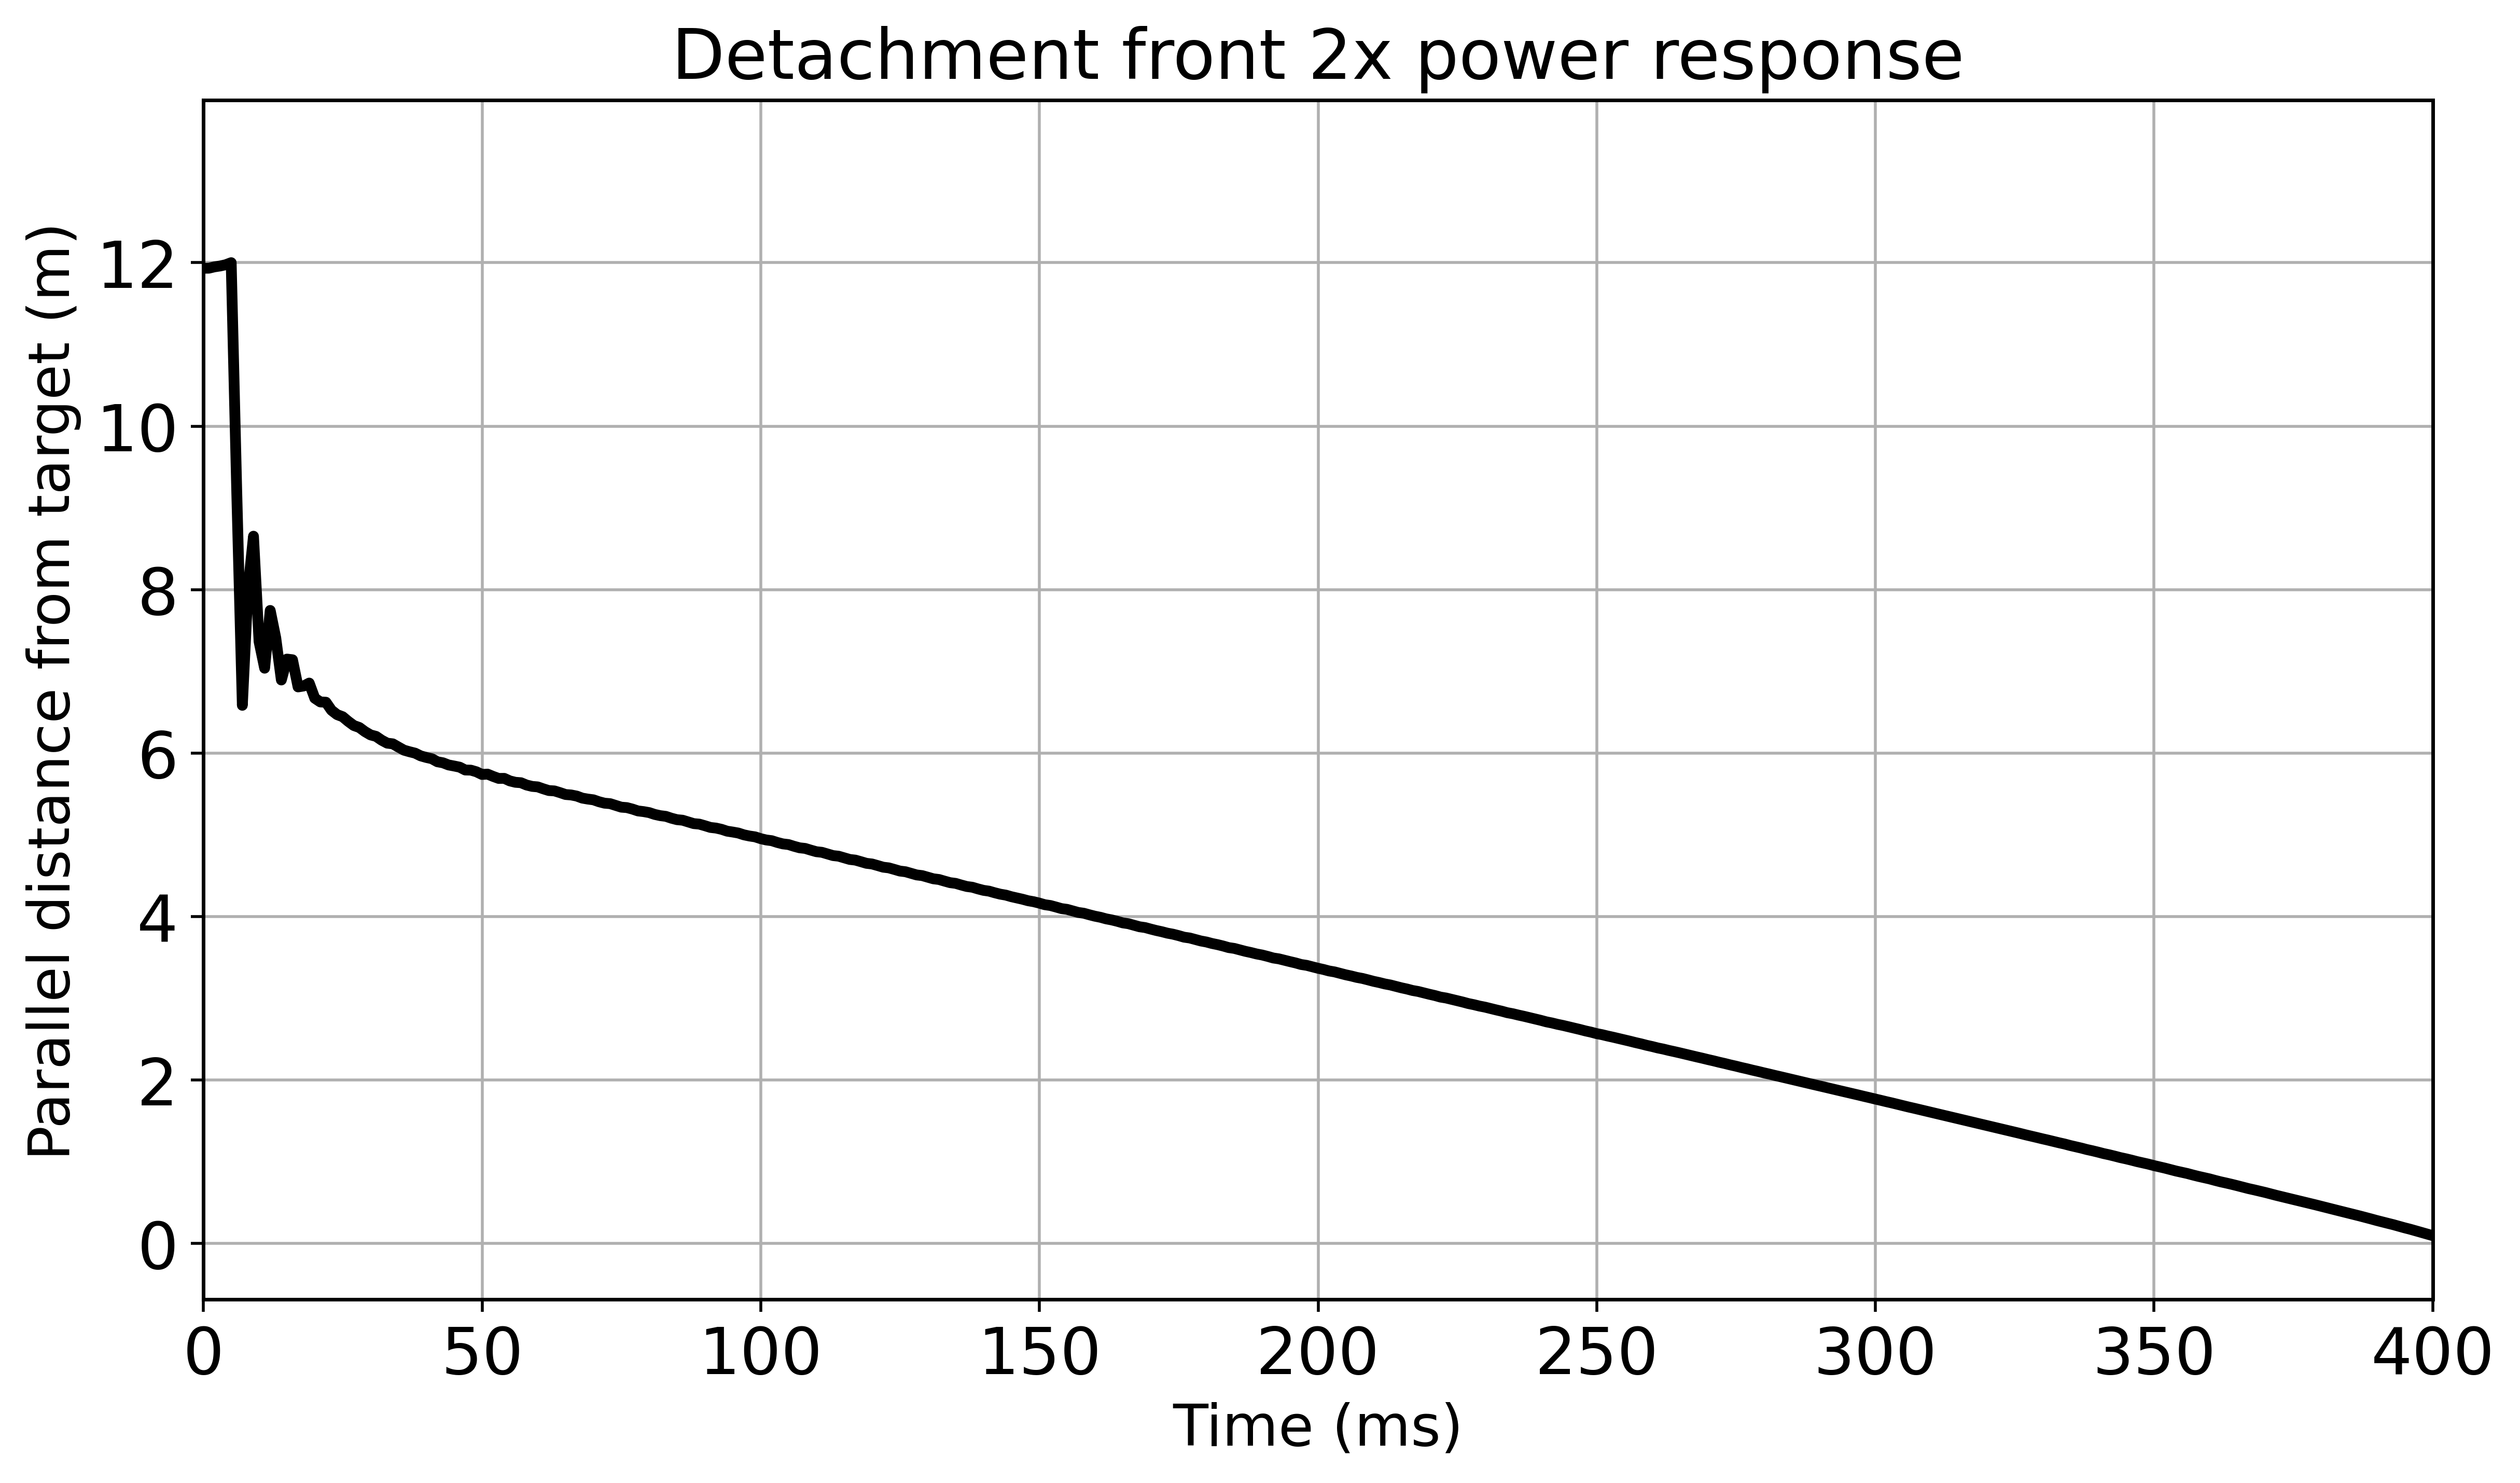

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=True, dpi=500)
detachment = 82 - det_front['front_pardist_5eV'].values
time = (det_front['t'].values - det_front['t'].values[0]) * 1e3 - 355    # Convert to ms
ax.plot(time, detachment, linewidth=linewidth, linestyle='-', color='black')
ax.set_xlabel('Time (ms)')
ax.set_ylabel(' Parallel distance from target (m)')
ax.set_title('Detachment front 2x power response')
# ax.set_xbound(355,800)   
ax.set_xbound(0, 400)
# ax.set_ybound(0, 7.5)
# ax.legend(loc='best')
plt.tight_layout()
plt.show()

# ionisation/recombination

1.3400760061105242e+28
time taken to ionise neutral cloud =  0.1925161138817336 ms


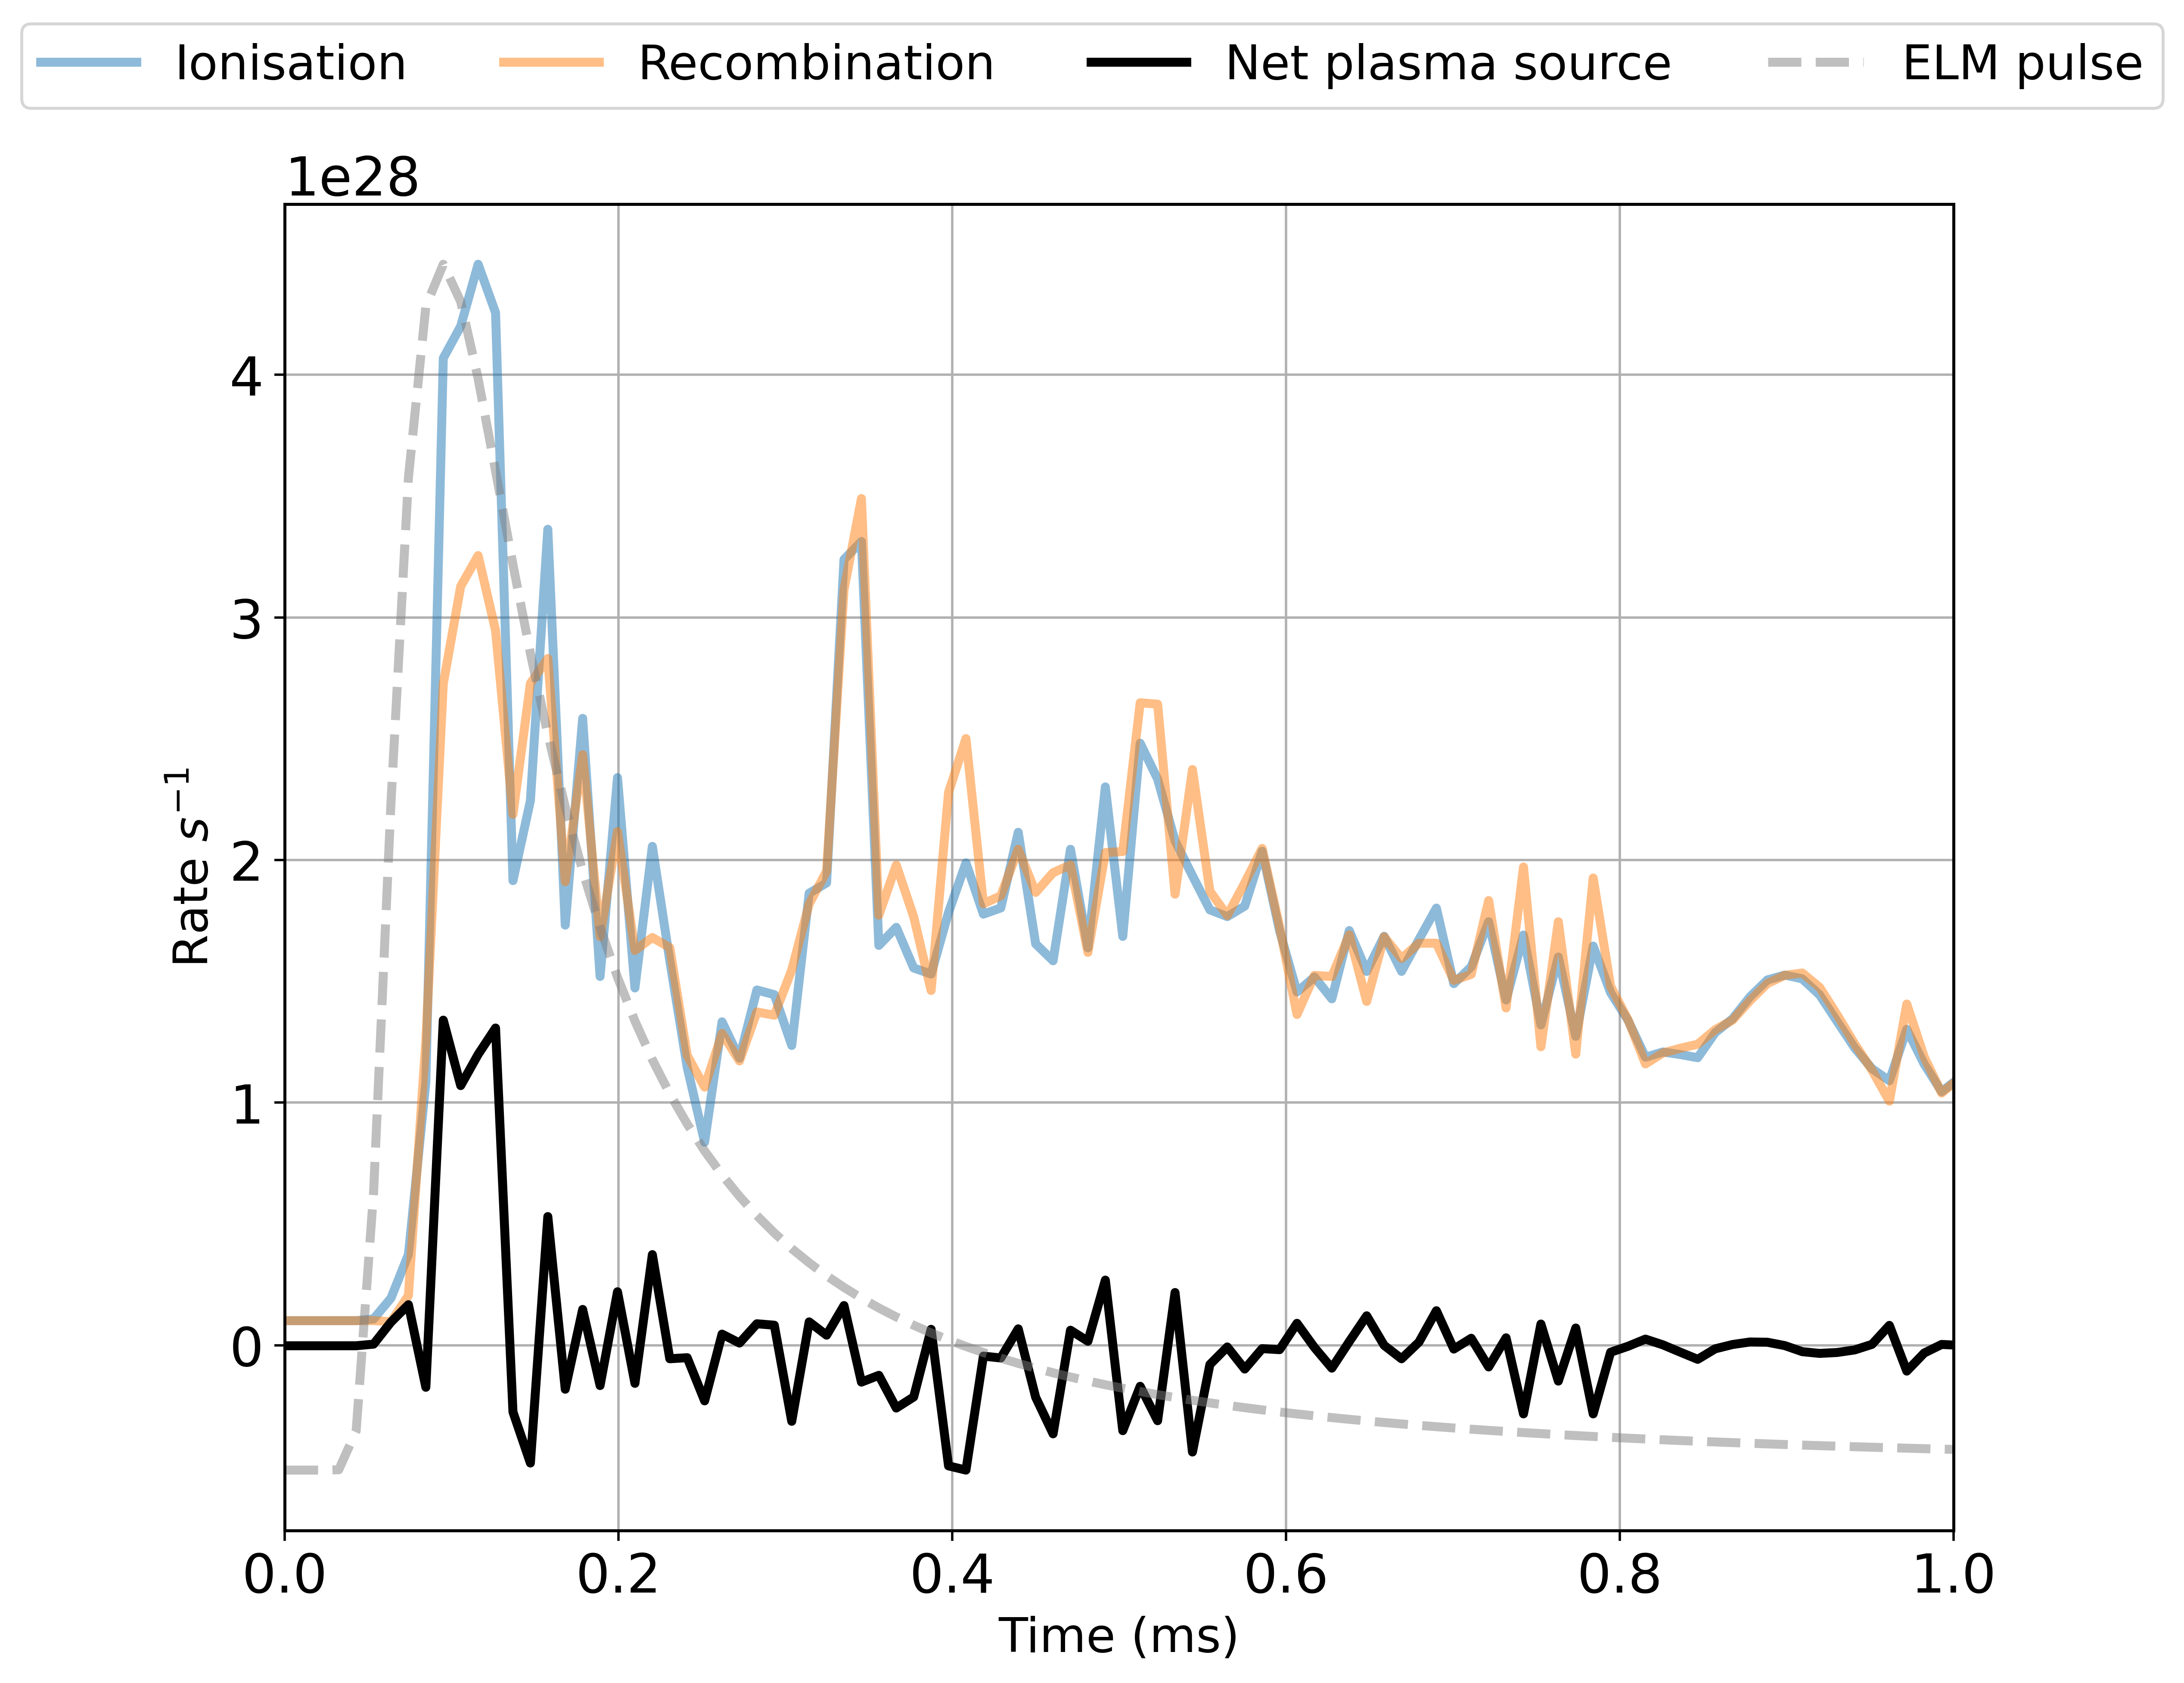

In [ ]:
import matplotlib.pyplot as plt

time_range = (0, 500)
ds = cs['300%_SNB'].ds
if time_range is not None:
    ds = ds.isel(t=slice(*time_range))
else:
    ds = ds.isel(t=slice(0, -1))

time = ((ds['t'].values - ds['t'].values[0]) *1e3) -0.5 # normalize time to start at 0

fig, ax = plt.subplots(figsize=(10, 8), dpi = 500)
ax2 = ax.twinx()

ionisation = (ds['Sd+_iz'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
recombination = (ds['Sd+_rec'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
target_recycle = (ds['Sd_target_recycle'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
sheath = (ds['Sd+_sheath'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
simple_pump_sink_d = (ds['simple_pump_sink_d'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
upstream_source_plasma = (ds['Sd+_src'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')
neutral_source = (ds['Sd_src'].isel(pos=slice(2, -2)) * ds['dv'].isel(pos=slice(2, -2))).sum(dim='pos')

# Calculate the net ionisation
net_ionisation = ionisation + recombination + target_recycle + sheath + simple_pump_sink_d

ax.plot(time, ionisation, label='Ionisation', linewidth=linewidth, markersize=markersize, alpha=0.5)
ax.plot(time, -1*recombination, label='Recombination', linewidth=linewidth, markersize=markersize, alpha=0.5)
# ax.plot(time, target_recycle, label='Target Recycle', linewidth=linewidth, markersize=markersize, alpha=0.5)
# ax.plot(time, -1*sheath, label='Sheath', linewidth=linewidth, markersize=markersize, alpha=0.5)
# ax.plot(time, -1*simple_pump_sink_d, label='Simple Pump Sink', linewidth=linewidth, markersize=markersize, alpha=0.5)
# Plot the net ionisation
ax.plot(time, net_ionisation, label='Net plasma source', linewidth=linewidth, markersize=markersize, linestyle='-', color='black')
ax2.plot(time, ds['Pe_src'].isel(pos=slice(2, -2)).sum(dim='pos') - ds['Pe_src'].isel(pos=slice(2, -2)).sum(dim='pos')[3], label='ELM pulse', color='grey', linewidth=linewidth, markersize=markersize, alpha=0.5, linestyle='--')

# ax.set_yscale('symlog')
ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'Rate $s^{-1}$')
ax2.grid(False)
# ax2.set_ylabel(r'pulse duration')
ax2.set_yticks([])
ax.set_xbound(0, 1)
fig.legend(ncols=4, loc='upper center')

print(np.max(net_ionisation.values))

print('time taken to ionise neutral cloud = ',  (2.579862250025524e+24 / np.max(net_ionisation.values))*1e3, 'ms')
    